In [7]:
#!/usr/bin/env python3
import os
from ase.io import read, write
import mdtraj as md

traj_file = "md_trajectory.traj"
top_file = "final_structure.pdb"       # ✅ 用来提供真实蛋白拓扑
out_dir = "protein_frames"
os.makedirs(out_dir, exist_ok=True)

print(f"📂 Reading ASE trajectory: {traj_file}")
images = read(traj_file, ":")
print(f"   Loaded {len(images)} frames.")

for i, img in enumerate(images):
    tmp_pdb = f"tmp_{i}.pdb"
    write(tmp_pdb, img)

    # 用真实拓扑加载该帧
    traj = md.load(tmp_pdb, top=top_file)
    protein_atoms = traj.topology.select("protein")
    traj_protein = traj.atom_slice(protein_atoms)

    out_path = os.path.join(out_dir, f"frame_{i+1:05d}.pdb")
    traj_protein.save_pdb(out_path)

    os.remove(tmp_pdb)
    if (i + 1) % 100 == 0:
        print(f"   Saved {i+1} frames...")

print(f"✅ Protein frames saved to {out_dir}/")


📂 Reading ASE trajectory: md_trajectory.traj
   Loaded 40001 frames.
   Saved 100 frames...
   Saved 200 frames...
   Saved 300 frames...
   Saved 400 frames...
   Saved 500 frames...
   Saved 600 frames...
   Saved 700 frames...
   Saved 800 frames...
   Saved 900 frames...
   Saved 1000 frames...
   Saved 1100 frames...
   Saved 1200 frames...
   Saved 1300 frames...
   Saved 1400 frames...
   Saved 1500 frames...
   Saved 1600 frames...
   Saved 1700 frames...
   Saved 1800 frames...
   Saved 1900 frames...
   Saved 2000 frames...
   Saved 2100 frames...
   Saved 2200 frames...
   Saved 2300 frames...
   Saved 2400 frames...
   Saved 2500 frames...
   Saved 2600 frames...
   Saved 2700 frames...
   Saved 2800 frames...
   Saved 2900 frames...
   Saved 3000 frames...
   Saved 3100 frames...
   Saved 3200 frames...
   Saved 3300 frames...
   Saved 3400 frames...
   Saved 3500 frames...
   Saved 3600 frames...
   Saved 3700 frames...
   Saved 3800 frames...
   Saved 3900 frames...
   S

⚠️  Found 40001 PDB files, evenly selected 1000 frames.


<Axes: title={'center': 'Batch (1000 files)'}, xlabel='φ [rad]', ylabel='ψ [rad]'>

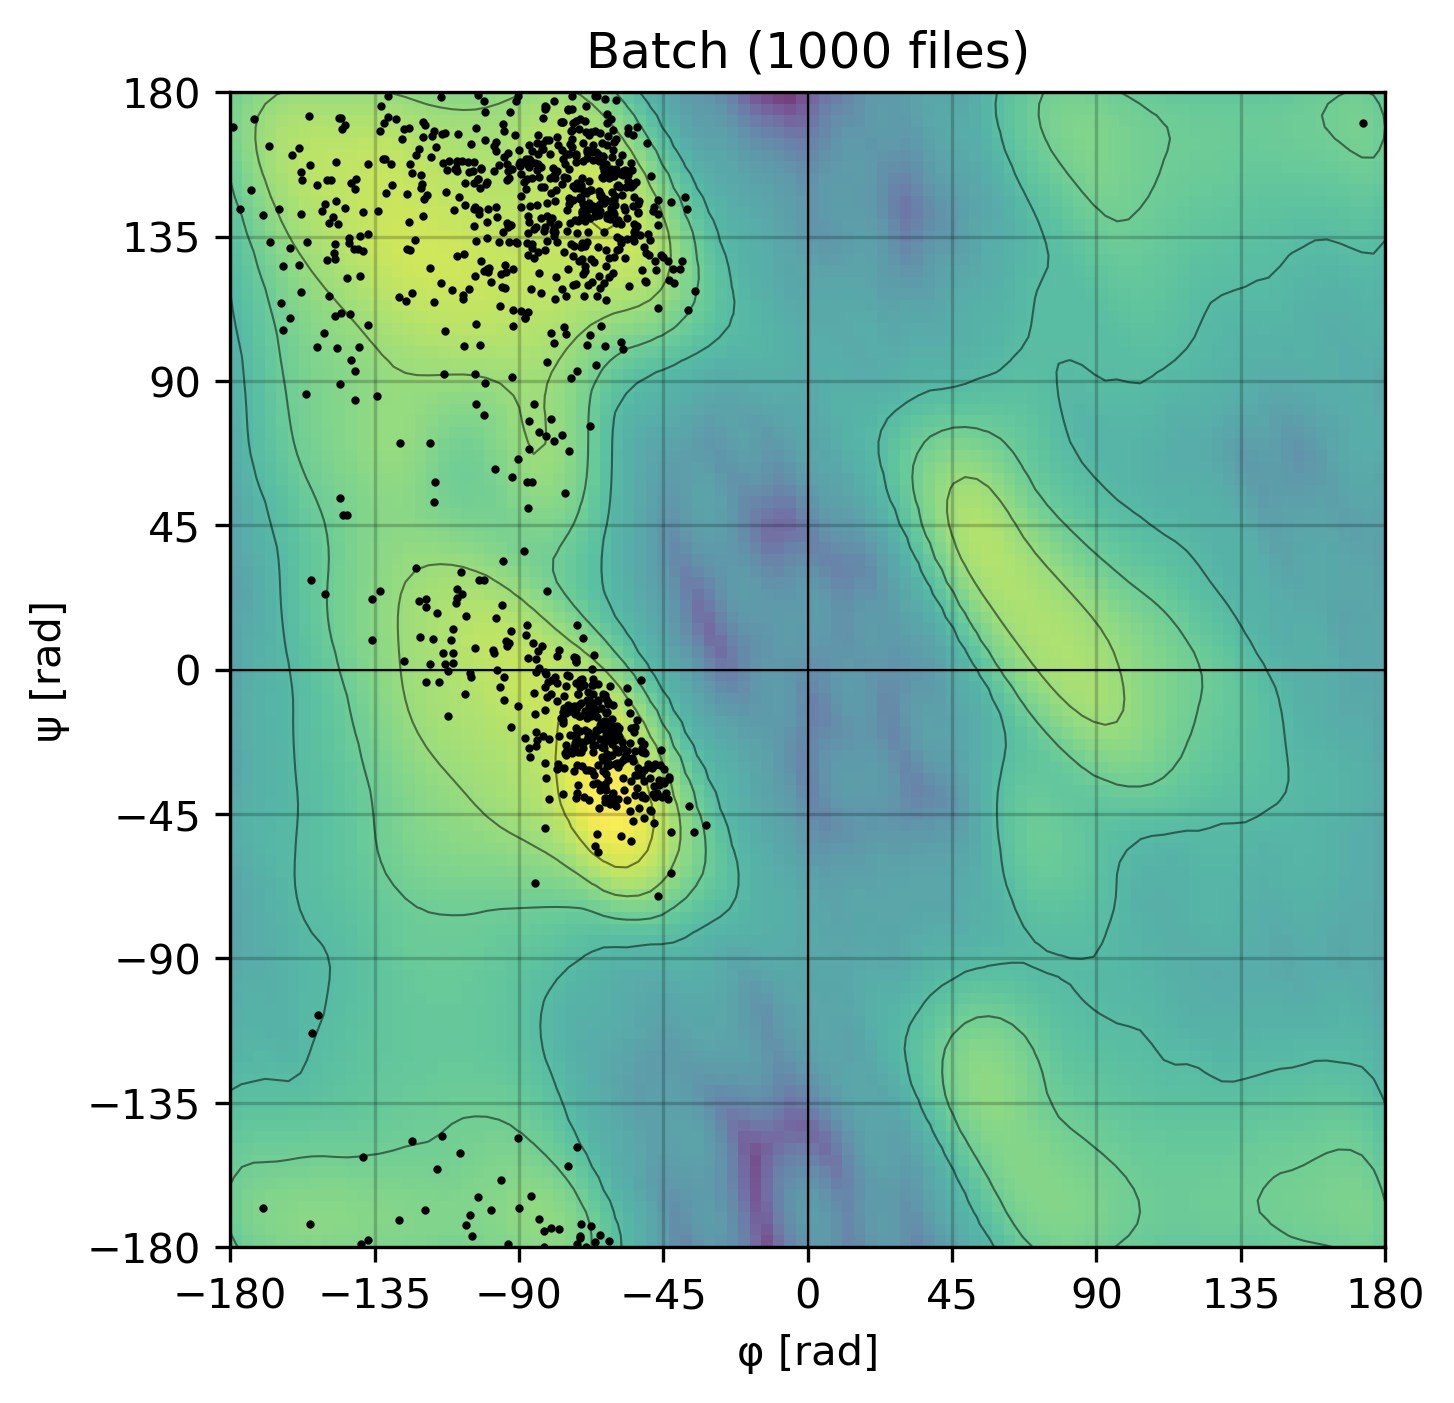

In [1]:
import glob
import numpy as np
from ramachandraw.utils import plot

# 找到所有符合条件的 PDB 文件
pdb_list = sorted(glob.glob("./protein_frames/frame_*.pdb"))
n_total = len(pdb_list)
max_files = 1000

if n_total == 0:
    raise RuntimeError("❌ No PDB files found in ./protein_frames/")
elif n_total > max_files:
    # 均匀取样 1000 个索引
    indices = np.linspace(0, n_total - 1, max_files, dtype=int)
    pdb_list = [pdb_list[i] for i in indices]
    print(f"⚠️  Found {n_total} PDB files, evenly selected {max_files} frames.")
else:
    print(f"✅ Found {n_total} PDB files, using all of them.")

# 调用绘图函数
plot(
    pdb_filepath=pdb_list,  # ✅ 注意这里传 list 而不是字符串
    cmap="viridis",
    alpha=0.75,
    dpi=300,
    save=True,
    show=False,
    filename="plot.png"
)


📂 Reading ASE trajectory: md_trajectory.traj
   Loaded 40001 frames, 1026 atoms each.
✅ Wrote temporary multi-frame PDB: ase_tmp.pdb
   Loaded 40001 frames, 1026 atoms.
✅ Selected 15 Ala heavy atoms.


mdtraj/rmsd/src/theobald_rmsd.cpp UNCONVERGED ROTATION MATRIX. RETURNING IDENTITY=300


✅ Saved RMSD plot to rmsd_vs_time_ala_heavy.png


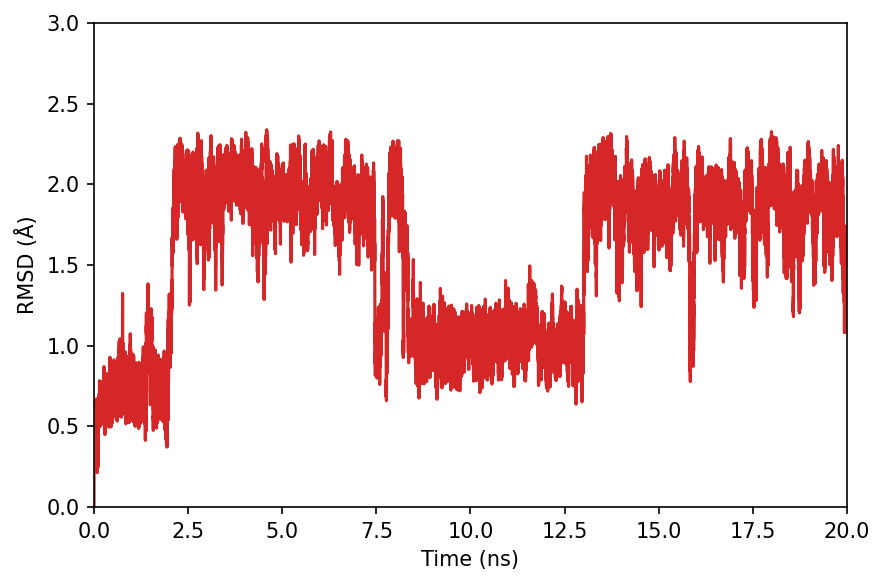

In [3]:
#!/usr/bin/env python3
import numpy as np
import matplotlib.pyplot as plt
from ase.io import read, write
import mdtraj as md

# ===== 输入文件 =====
traj_file = "md_trajectory.traj"
top_file = "final_structure.pdb"   # 拓扑信息
out_png = "rmsd_vs_time_ala_heavy.png"

# ===== 1️⃣ 读取 ASE 轨迹 =====
print(f"📂 Reading ASE trajectory: {traj_file}")
images = read(traj_file, ":")
n_frames = len(images)
n_atoms = len(images[0])
print(f"   Loaded {n_frames} frames, {n_atoms} atoms each.")

# ===== 2️⃣ 导出临时多帧 PDB =====
tmp_pdb = "ase_tmp.pdb"
write(tmp_pdb, images)
print(f"✅ Wrote temporary multi-frame PDB: {tmp_pdb}")

# ===== 3️⃣ 用 MDTraj 加载轨迹 =====
traj = md.load(tmp_pdb, top=top_file)
print(f"   Loaded {traj.n_frames} frames, {traj.n_atoms} atoms.")

# ===== 4️⃣ 选择 Ala 重原子 =====
# "resname ALA" 选择 Ala 残基；"not element H" 排除氢
ala_heavy_atoms = traj.topology.select("resname ALA and not element H")
if len(ala_heavy_atoms) == 0:
    raise RuntimeError("❌ No Ala heavy atoms found — check topology or atom names.")
print(f"✅ Selected {len(ala_heavy_atoms)} Ala heavy atoms.")

# 提取 Ala 重原子轨迹
traj_ala = traj.atom_slice(ala_heavy_atoms)

# ===== 5️⃣ 对齐并计算 RMSD =====
ref = traj_ala[0]
traj_ala.superpose(ref)                   # 对齐到第一帧
rmsd = md.rmsd(traj_ala, ref) * 10.0      # nm → Å

# ===== 6️⃣ 生成时间数组 =====
time_ps = np.arange(n_frames)             # 或者实际时间：np.arange(n_frames) * timestep_ps

# ===== 6️⃣ 生成时间数组（单位：ns）=====
timestep_fs = 500.0
timestep_ns = timestep_fs * 1e-6
time_ns = np.arange(n_frames) * timestep_ns

# ===== 7️⃣ 绘制 RMSD 曲线 =====
plt.figure(figsize=(6, 4), dpi=150)
plt.plot(time_ns, rmsd, lw=1.5, color="tab:red")
plt.xlim(0,20)
plt.ylim(0,3)
plt.xlabel("Time (ns)")
plt.ylabel("RMSD (Å)")
plt.tight_layout()
plt.savefig(out_png)
print(f"✅ Saved RMSD plot to {out_png}")
plt.show()


In [1]:
import mdtraj as md
from biceps.J_coupling import *


# 加载轨迹
traj = md.load("md_trajectory.xtc", top="final_structure.pdb")


# 分别计算
_, J_HA, mean_HA, std_HA = compute_J3_HN_HA(traj)
_, J_CB, mean_CB, std_CB = compute_J3_HN_CB(traj)
_, J_CP, mean_CP, std_CP = compute_J3_HN_CP(traj)

# 输出每个残基结果
for i in range(len(mean_HA)):
    print(f"Residue {i+1:2d} | ³J(HN,Hα): {mean_HA[i]:6.2f} ± {std_HA[i]:4.2f} | "
          f"³J(HN,Cβ): {mean_CB[i]:6.2f} ± {std_CB[i]:4.2f} | "
          f"³J(HN,C′): {mean_CP[i]:6.2f} ± {std_CP[i]:4.2f}")

BICePs - Bayesian Inference of Conformational Populations, Version 2.0


Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.

********* JAX NOT FOUND *********
 PyMBAR can run faster with JAX  
 But will work fine without it   
Either install with pip or conda:
      pip install pybar[jax]     
               OR                
      conda install pymbar       
*********************************


Residue  1 | ³J(HN,Hα):   5.70 ± 0.26 | ³J(HN,Cβ):   1.85 ± 0.07 | ³J(HN,C′):   0.65 ± 0.04
Residue  2 | ³J(HN,Hα):   5.54 ± 0.20 | ³J(HN,Cβ):   1.85 ± 0.07 | ³J(HN,C′):   0.79 ± 0.08
Residue  3 | ³J(HN,Hα):   6.00 ± 0.08 | ³J(HN,Cβ):   1.79 ± 0.04 | ³J(HN,C′):   0.73 ± 0.07
